In [27]:
import pandas as pd
import numpy as np

Loading the data into Jupyterlab

In [28]:
data = pd.read_csv("OnlineRetail.csv",encoding="ISO-8859-1")
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


dataset shap

In [29]:
data.shape

(541909, 8)

Check datasetcolumns

In [30]:
data.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Check Datatypes

In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


Check Nullvalues in the dataset

In [32]:
data.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Summary statistics

In [33]:
data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


Duplicated Records

In [34]:
data.duplicated().sum()

np.int64(5268)

Negative Quantities

In [35]:
data[data["Quantity"] < 0].shape

(10624, 8)

Unique Customers

In [36]:
data["CustomerID"].nunique()

4372

Unique Products

In [37]:
data["StockCode"].nunique()

4070

#Key Observations 

Total Records
541,909 rows
8 columns

Missing Values
Description : 1,454
CustomerID  : 135,080

Duplicate Rows
5,268 duplicates

Returns / Cancellations
10,624 rows with negative Quantity

Unique Customers
4,372 customers

Unique Products
4,070 products

describe():

Quantity Min = -80995
UnitPrice Min = -11062.06

Negative Quantity = Returns/Cancellations

Negative UnitPrice = Adjustments/Credits

Check negative prices

In [38]:
data[data['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,12-08-2011 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,12-08-2011 14:52,-11062.06,NaN,United Kingdom


Check zero prices

In [39]:
data[data['UnitPrice'] == 0].shape

(2515, 8)

Check invoice numbers starting with C

In [40]:
data[data['InvoiceNo'].astype(str).str.startswith('C')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,01-12-2010 09:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,01-12-2010 09:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,01-12-2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,01-12-2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,01-12-2010 10:24,0.29,17548.0,United Kingdom


Number of Cancelled Orders

In [41]:
data[data['InvoiceNo'].astype(str).str.startswith('C')].shape

(9288, 8)

Remove missing CustomerID

Cannot build customer clusters without customer IDs.

In [42]:
data = data.dropna(subset=['CustomerID'])

Remove duplicates

In [43]:
data = data.drop_duplicates()

Remove returns

In [44]:
data = data[data['Quantity'] > 0]

Remove zero/negative prices

In [45]:
data = data[data['UnitPrice'] > 0]

Create a Revenue for caluculating total revenue

In [46]:
data["Revenue"] = data["Quantity"]*data["UnitPrice"]

Convert Date

In [47]:
data['InvoiceDate'] = pd.to_datetime(
    data['InvoiceDate'],
    format='%d-%m-%Y %H:%M'
)

In [48]:
data['InvoiceDate'].head()

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]

In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   Revenue      392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


Extract Features

In [50]:
data['Year'] = data['InvoiceDate'].dt.year
data['Month'] = data['InvoiceDate'].dt.month
data['MonthName'] = data['InvoiceDate'].dt.month_name()
data['Quarter'] = data['InvoiceDate'].dt.quarter
data['DayName'] = data['InvoiceDate'].dt.day_name()
data['Hour'] = data['InvoiceDate'].dt.hour

In [51]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,MonthName,Quarter,DayName,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,December,4,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,4,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,December,4,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,4,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,4,Wednesday,8


In [52]:
data.shape


(392692, 15)

Original Rows:541909
Rows After Cleaning:392692
Rows Removed:149,217

Revenues KPI'S

In [53]:
total_revenue = data["Revenue"].sum()

In [54]:
total_customers = data["CustomerID"].nunique()

In [55]:
total_orders = data["InvoiceNo"].nunique()

In [56]:
avg_order_value = total_revenue / total_orders

In [57]:
print("Total Revenue:", round(total_revenue,2))
print("Total Customers:", total_customers)
print("Total Orders:", total_orders)
print("Average Order Value:", round(avg_order_value,2))

Total Revenue: 8887208.89
Total Customers: 4338
Total Orders: 18532
Average Order Value: 479.56


The company generated £8.89 million in revenue from 4,338 customers and 18,532 completed orders.

On average, each order contributed £479.56 in revenue. The large revenue base combined with thousands of customers makes this dataset well-suited for identifying high-value customers, loyal buyers, and at-risk customer segments through clustering techniques.

In [58]:
df = data.copy()


In [59]:
data.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month',
       'MonthName', 'Quarter', 'DayName', 'Hour'],
      dtype='object')

In [60]:
country_revenue = (
    data.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    )
country_revenue

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

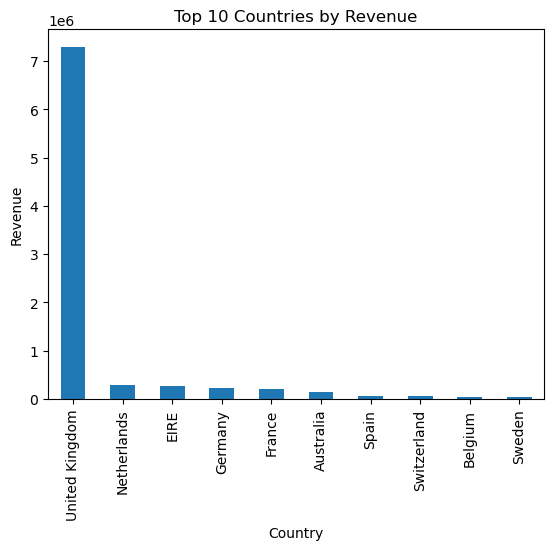

In [61]:
import matplotlib.pyplot as plt

country_revenue.plot(kind='bar')

plt.title('Top 10 Countries by Revenue')
plt.ylabel('Revenue')
plt.show()

### Insight
- United Kingdom generated the highest revenue by a significant margin, contributing more than 80% of total sales among the top 10 countries.
- Netherlands and Germany were the next strongest markets, but far behind the United Kingdom.

In [62]:
monthly_revenue = (
    data.groupby(['Year','Month'])['Revenue']
    .sum()
    .reset_index()
)

monthly_revenue

,Year,Month,Revenue
0,2010,12,570422.730
1,2011,1,568101.310
2,2011,2,446084.920
3,2011,3,594081.760
4,2011,4,468374.331
5,2011,5,677355.150
6,2011,6,660046.050
7,2011,7,598962.901
8,2011,8,644051.040
9,2011,9,950690.202


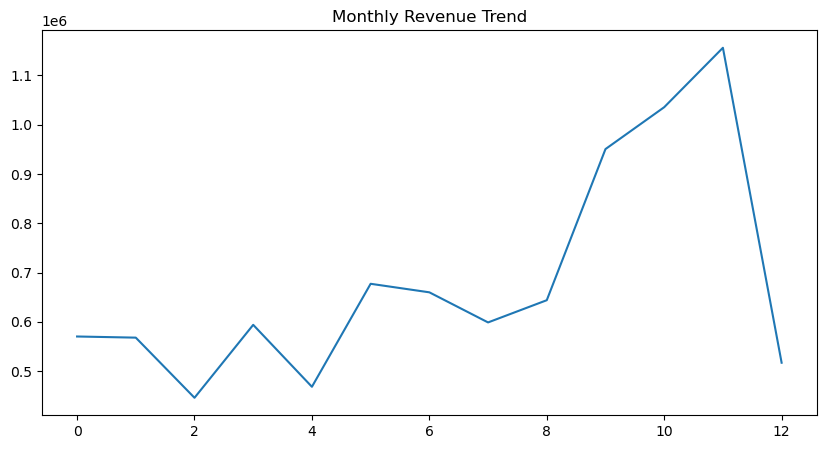

In [63]:
plt.figure(figsize=(10,5))

plt.plot(monthly_revenue.index,
         monthly_revenue['Revenue'])

plt.title("Monthly Revenue Trend")
plt.show()

### Insight
- Revenue showed an overall upward trend throughout the year.
- November recorded the highest revenue, indicating strong seasonal demand and holiday shopping activity.
- Revenue dropped sharply in December because the dataset contains only partial December transactions.

In [64]:
top_products = (
    data.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

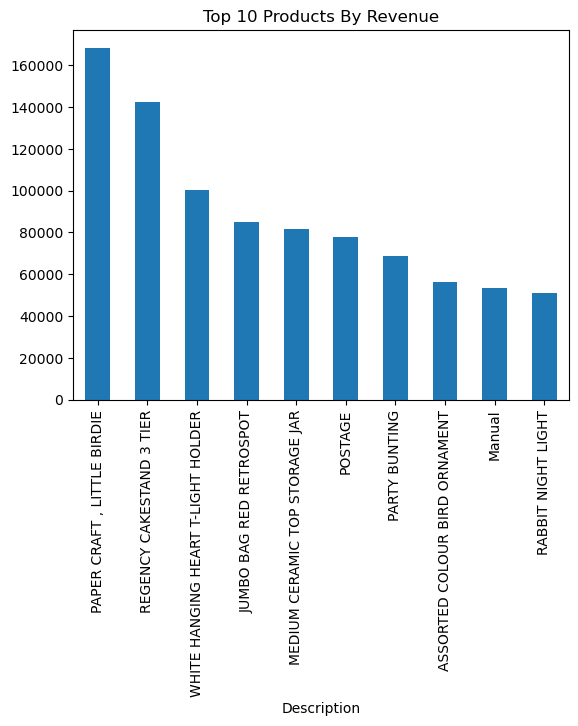

In [65]:
top_products.plot(kind='bar')

plt.title("Top 10 Products By Revenue")

plt.show()

### Insight
- PAPER CRAFT , LITTLE BIRDIE generated the highest revenue among all products.
- The top-selling products contributed a significant portion of overall business revenue.
- Home decor and gift-related products dominated the revenue rankings.

In [66]:
top_customers = (
    data.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

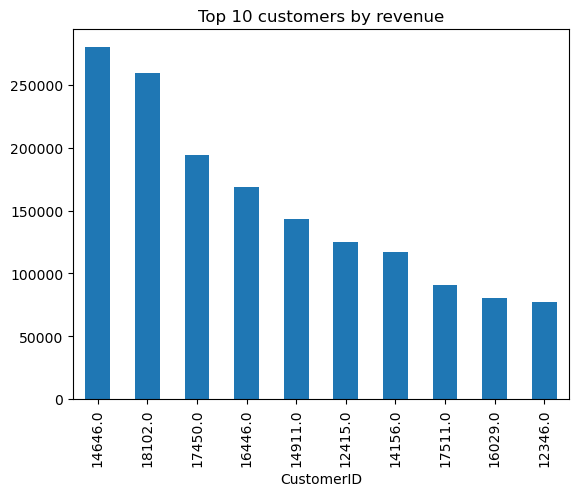

In [67]:
top_customers.plot(kind="bar")
plt.title("Top 10 customers by revenue")
plt.show()

### Insight
- Customer 14646 generated the highest revenue for the business.
- A small number of customers contributed a large share of total revenue.
- Retaining high-value customers is critical for business growth.

In [68]:
hourly_revenue = (
    data.groupby('Hour')['Revenue']
    .sum()
)

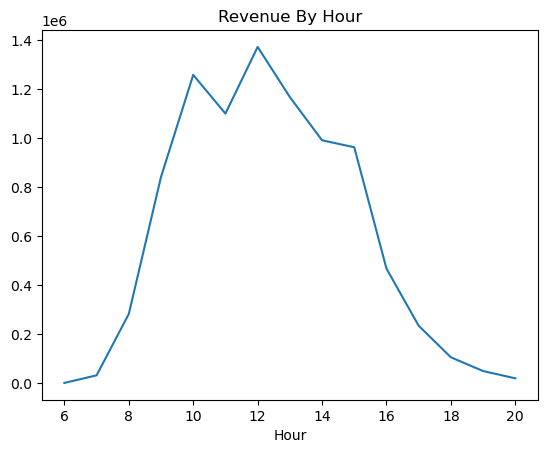

In [69]:
hourly_revenue.plot()

plt.title("Revenue By Hour")

plt.show()

### Insight
- Revenue peaked at 13:00 (1 PM), making it the busiest sales hour.
- Most purchases occurred between 10 AM and 3 PM.
- Sales activity declined significantly after 4 PM.

In [70]:
day_revenue = (
    data.groupby('DayName')['Revenue']
    .sum()
)

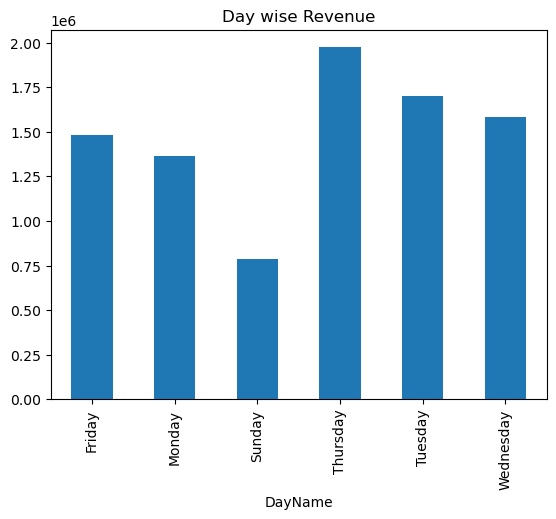

In [71]:
day_revenue.plot(kind="bar")
plt.title("Day wise Revenue")
plt.show()

### Insight
- Thursday generated the highest revenue among all weekdays.
- Sunday recorded the lowest revenue.
- Mid-week days generally produced stronger sales performance than weekends.

# Customer Segmentation (RFM Analysis)

In [73]:
snapshot_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head().reset_index()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [74]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

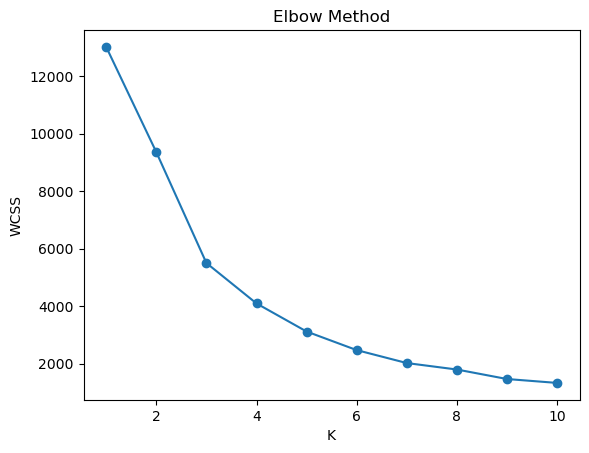

In [76]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

In [77]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)

    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.5604
K=3, Silhouette Score=0.5853
K=4, Silhouette Score=0.6162
K=5, Silhouette Score=0.6165
K=6, Silhouette Score=0.5983
K=7, Silhouette Score=0.5171


### Insight

- The Elbow Method suggested an optimal cluster range between 3 and 4.
- Silhouette analysis showed the highest score at K=5 (0.6165), while K=4 achieved a nearly identical score (0.6162).
- Since K=4 provides simpler and more interpretable customer segments with minimal loss in clustering quality, K=4 was selected for the final customer segmentation model.

In [78]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head().reset_index()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


In [79]:
rfm["Cluster"].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

In [80]:
rfm.groupby("Cluster").agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean"
}).round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


### Customer Segment Insights

- Cluster 2 contains a very small group of customers but generates the highest revenue.
- These customers purchase frequently and have purchased very recently, making them VIP customers.
- Cluster 3 represents loyal high-value customers with strong purchasing behavior.
- Cluster 0 consists of regular customers with moderate spending and purchase frequency.
- Cluster 1 contains inactive customers who have not purchased recently and contribute the least revenue.

In [81]:
cluster_profile = rfm.groupby("Cluster").agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean"
}).round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


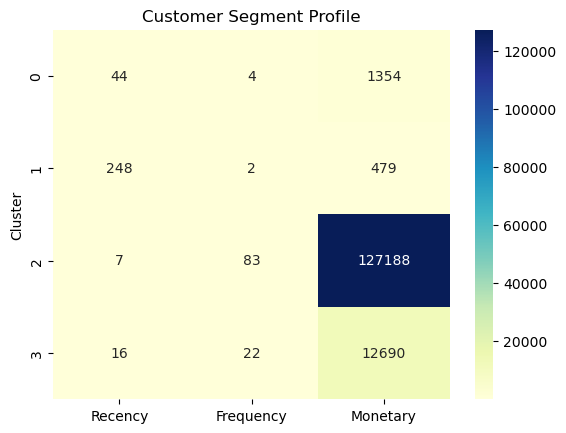

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cluster_profile,
            annot=True,
            fmt=".0f",
            cmap="YlGnBu")

plt.title("Customer Segment Profile")
plt.show()

### Insight
- Cluster 2 represents VIP customers with the highest spending (£127,188), highest purchase frequency (83 orders), and very recent activity (7 days).
- Cluster 3 consists of loyal high-value customers who purchase frequently and contribute significant revenue.
- Cluster 0 contains regular customers with moderate spending and purchase frequency.
- Cluster 1 represents inactive customers with low spending, low purchase frequency, and the highest recency value (248 days).
- The business should focus on retaining Cluster 2 and Cluster 3 customers while creating re-engagement campaigns for Cluster 1 customers.

In [83]:
segment_names = {
    0: "Regular Customers",
    1: "Lost Customers",
    2: "VIP Customers",
    3: "Loyal Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

In [84]:
rfm

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Loyal Customers
12347.0,2,7,4310.00,0,Regular Customers
12348.0,75,4,1797.24,0,Regular Customers
12349.0,19,1,1757.55,0,Regular Customers
12350.0,310,1,334.40,1,Lost Customers
...,...,...,...,...,...
18280.0,278,1,180.60,1,Lost Customers
18281.0,181,1,80.82,1,Lost Customers
18282.0,8,2,178.05,0,Regular Customers


# Exporting Final Datasets

In [85]:
# Cleaned Retail Dataset
data.to_csv("cleaned_retail_data.csv", index=False)

# RFM Dataset
rfm.to_csv("rfm_customer_segments.csv")

print("Files Exported Successfully")

Files Exported Successfully


In [86]:
import os

print(os.getcwd())

C:\Users\shanm\OnlineretailUnsupervised


In [90]:
import os

print(os.path.abspath("rfm_customer_segments.csv"))

C:\Users\shanm\OnlineretailUnsupervised\rfm_customer_segments.csv


In [91]:
print(data.shape)

print(data["CustomerID"].nunique())

print(data["InvoiceDate"].min())

print(data["InvoiceDate"].max())

(392692, 15)
4338
2010-12-01 08:26:00
2011-12-09 12:50:00
